# Does the ZigZag indicator actually call tradable turns? ⚡
### A famous swing filter — connect the swings, buy the turn — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![ZigZag_tradable%3F: Busted](https://img.shields.io/badge/ZigZag_tradable%3F-Busted-8b949e?style=flat-square)

Open any charting package and you'll find the **ZigZag**: it ignores the wiggles and draws clean straight legs between the real swing highs and lows, snapping a new leg only when price reverses by more than some percentage (5% here). The lore, repeated on every chart-pattern site and baked into MetaTrader, TradingView and the Elliott-wave tools, is that the ZigZag **identifies the turns**: when it turns **up** off a swing low, that low was a tradable bottom — so you buy.

It *looks* uncanny, because on a finished chart the ZigZag's lows sit exactly on the bottoms. But there's a catch the tool hides: the newest leg **repaints**. The indicator draws it to the latest price and then **erases and redraws** it as price moves — the 'perfect' low you see was only knowable *after* the bounce. So we did the only fair thing: trade **confirmed** legs only (the bounce has already happened, no peeking), fire the 'buy the turn' rule across five big indices over 21 years, and time the result against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from zigzag_indicator import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real zigzag cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 428, 'pct': 0.05, 'fp_spy': '4cb5244f3990', 'h5': (5, 428, -5.9, 56, -0.32, 17.8, -23.7, -7.9, -1.04, 0.298), 'h10': (10, 428, 39.6, 61, 1.62, 29.0, 10.6, 37.6, 0.34, 0.734), 'h20': (20, 428, 111.9, 64, 2.87, 53.4, 58.5, 109.9, 1.33, 0.183), 'h60': (60, 423, 370.3, 66, 4.35, 222.2, 148.1, 368.3, 2.12, 0.034), 'per': [('SPY', 78, 94.3, 0.98, 58.9, 35.4), ('QQQ', 91, 152.0, 1.56, 87.9, 64.1), ('IWM', 115, 139.2, 1.65, 36.5, 102.7), ('DIA', 70, 97.0, 1.25, 50.6, 46.4), ('GLD', 74, 52.9, 1.13, 34.6, 18.3)], 'placebo': (94.3, 0.645, 500), 'syn': [(0.0, 57, -1.0, 51, -0.01), (0.4, 52, 435.0, 81, 5.37)]}


real zigzag cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when the ZigZag turns up (a confirmed low), do I make money? | **In absolute terms, yes — but mostly because the market goes up.** Win-rate ~64% at 20 days, returns look fine. |
| Is that *the ZigZag's* doing? | **No.** Buy on **random days** instead and you do **just as well** at 5/10/20 days. The turn signal adds nothing over a dart at the horizons a 'turn' is supposed to live on. |
| Does the up/down *structure* matter? | **No.** Randomly relabel which confirmation dates count as 'lows' and the result barely changes — any confirmation date is as good as a real one. |
| So is it a tradable turn signal? | **No.** It's **beta in a costume** plus a slow post-pullback drift you'd get more cheaply by holding the index. |

> The ZigZag is a great way to *describe* the swings after the fact. As a *forecast* — 'this low will bounce' — it's a **mirage**: strip the repaint and the random-day baseline, and the turns stop being tradable.

## 1 · The claim

> *"The ZigZag filters out the noise: it only marks a swing when price reverses more than x%. When it turns up off a low, that low is confirmed — a high-probability bottom. Buy the turn."*

This is the classic **threshold ZigZag** (MetaTrader's *Depth/Deviation/Backstep*, TradingView's ZigZag), the pivot engine under **Elliott Wave** and **harmonic patterns**. It's one of the most recognisable tools in technical analysis — so: do its turns actually turn?

## 2 · So what?

If the ZigZag genuinely *forecast* the turn, it would be remarkable: a percentage rule on past price would flag future bottoms, a clean crack in market efficiency you could trade with a ruler. That's the dream the tool sells.

But two traps are built in. **(1) Repaint.** The newest leg is provisional — drawn to the latest extreme and redrawn as price moves. The 'perfect' low is only known *after* the bounce, so a naive backtest peeks at the future. **(2) Drift.** Stock indices climb over time, so *any* dip-buying rule looks profitable. To separate the **tool** from the **tide**, we (a) trade only **confirmed** legs (no repaint) and (b) compare to buying on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Build the ZigZag mechanically.** A new leg snaps only when price reverses **5%** off the running extreme — the textbook threshold filter.
2. **Remove the repaint.** A swing low is only *confirmed* once price has rebounded **5%** above it. We use that confirmation bar — never the future-peeking final pivot.
3. **Trade the lore.** When a low confirms (the ZigZag turns up), buy at the next close; measure the return over the next **5 / 10 / 20 / 60 days**.
4. **The honest baseline.** Do the exact same hold on **random days**. If the turn matters, the up-leg must beat random. *If it doesn't, the tool is a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical ZigZag even look like? Here's SPY with the (repainting, display-only) ZigZag line and the **confirmed** up-leg buys the rule would actually fire.

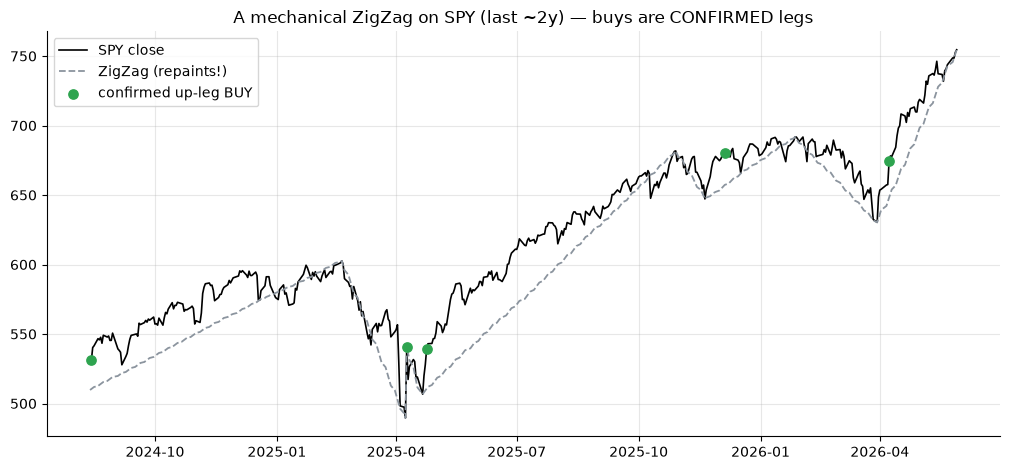

confirmed up-legs in window: 5


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    cl = b['close']; seg = cl.iloc[-450:]
    zz = st.zigzag_line(cl, pct=R['pct'])
    ent = st.confirmed_uppleg_entries(cl, pct=R['pct'])
    ent = ent[ent >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg.values, c='k', lw=1.2, label='SPY close')
    ax.plot(seg.index, zz.reindex(seg.index), c=GREY, lw=1.3, ls='--', label='ZigZag (repaints!)')
    ax.scatter(ent, cl.reindex(ent), c=GREEN, s=45, zorder=5, label='confirmed up-leg BUY')
    ax.set_title('A mechanical ZigZag on SPY (last ~2y) — buys are CONFIRMED legs')
    ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('confirmed up-legs in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

Notice the green buys sit a few bars *after* each low — that's the confirmation lag (the honest, non-repainting version). The question is whether those buys are followed by bounces. **Let's race the confirmed up-leg against random entries** at four horizons. Blue = buy the turn; grey = buy on random days.

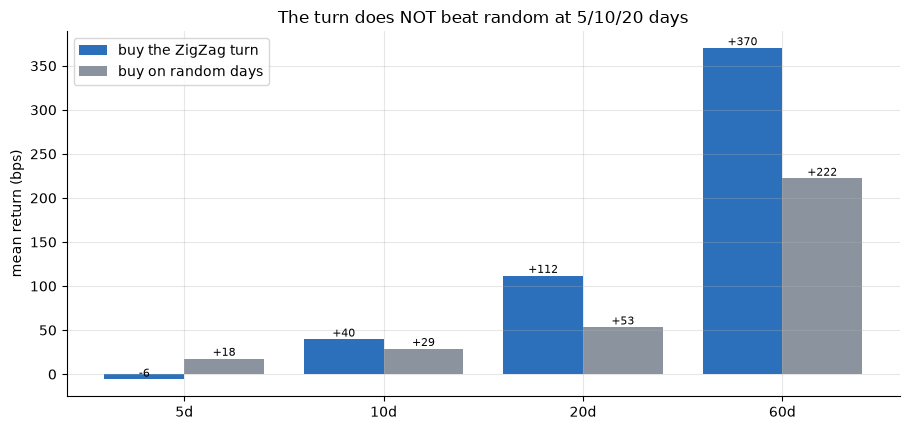

up-leg: [-6, 40, 112, 370]
random: [18, 29, 53, 222]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    upleg, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.confirmed_uppleg_entries(c, pct=R['pct'])
            re = st.random_entries(c, max(len(e),50), pct=R['pct'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        upleg.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    upleg = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, upleg, .4, color='#2c6fbb', label='buy the ZigZag turn')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(upleg,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The turn does NOT beat random at 5/10/20 days'); ax.legend()
plt.tight_layout(); plt.show()
print('up-leg:', [round(v) for v in upleg]); print('random:', [round(v) for v in rnd])

There's the story. The turn makes money in absolute terms (**+112 bps** over 20 days) — but at 5 days it's actually *worse* than random, and at 10/20 days it's a statistical coin-flip (the quants notebook shows the Welch *t* never clears 2 until 60 days). The apparent edge was **the market's upward drift**, not the turn.

**One more sanity check.** What if we keep the exact same confirmation dates but **randomly relabel** which ones count as 'lows' (the buys)? If the ZigZag's up/down structure really matters, the nonsense labels should do much worse.

In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.shuffled_leg_placebo(c, 20, pct=R['pct'], n_draws=300, seed=481)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real ZigZag confirmed-up-leg (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *relabelled-leg* runs do at least as well (p={pval:.2f}).')
print('=> the up/down structure is not doing the work.')

real ZigZag confirmed-up-leg (SPY, 20d): +94.3 bps
... but 65% of *relabelled-leg* runs do at least as well (p=0.65).
=> the up/down structure is not doing the work.


Almost two-thirds of the **relabelled** runs match or beat the real turn (*p* = 0.65). If the ZigZag genuinely picked *the* tradable lows, random labels would collapse the result. They don't — because the result was never about the up/down structure, just about clustering near volatile pullbacks.

## 5 · The verdict

- **Signal — None.** The confirmed turn does **not** beat buying on random days at 5/10/20 days (worse at 5d; a coin-flip at 10/20d). Only 60 days noses ahead, and the placebo shows even that isn't the ZigZag's geometry. The big absolute returns are drift.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and costs only make it worse.
- **"The ZigZag calls tradable turns"? — Busted.** Relabel the legs into nonsense and the result barely moves. The turns don't turn.

## 6 · Could you actually trade it?

There's nothing here to trade. The turn's *only* edge over a coin flip is the market's long-run climb plus a slow post-pullback drift — which you'd capture more cheaply (and more fully) by just **holding the index**. The ZigZag buy is a worse, more expensive way to be long, and it depends on a confirmation that arrives *after* the bottom you wanted. Costs push the already-no-edge result further negative. As a forecasting tool it doesn't pay; as a drawing tool it was never meant to be a strategy.

## 7 · Going further 🚪

- **The repaint demo.** The single most useful follow-up: plot the ZigZag as it *was* in real time vs the finished line, and watch the last leg jump around. Most backtests secretly trade the finished line.
- **Different thresholds.** Try 3% / 8% / 10% — the result is robust: drift in, ZigZag out.
- **A real positive control.** The quants notebook plants a *genuine* post-turn drift into a synthetic tape and shows the harness banks it (so the null here isn't a dead detector — it's an honest 'nothing there').

*Think the ZigZag forecasts turns? Show the confirmed up-leg beating random entries at **t ≥ 2** *and* surviving the relabelled-leg placebo on a real tape — then we'll talk.*